---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)
- NTP ICE에서 Acute Oral Toxicity, Skin Sensitization 2개 데이터셋 활용
- RDKit 2D descriptor(217개), ECFP4(2048개), MACCS Keys(167개), RDKit Fingerprint(2048개) 총 4종 descriptor 계산
- PubChem API를 통한 SMILES 보충 시도 (결과: 염 형태 화합물은 대체 불가)

# 기말고사 Template 1 — Data Pipeline

**이름:** 조윤성 &nbsp; **학번:** 20230085 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem


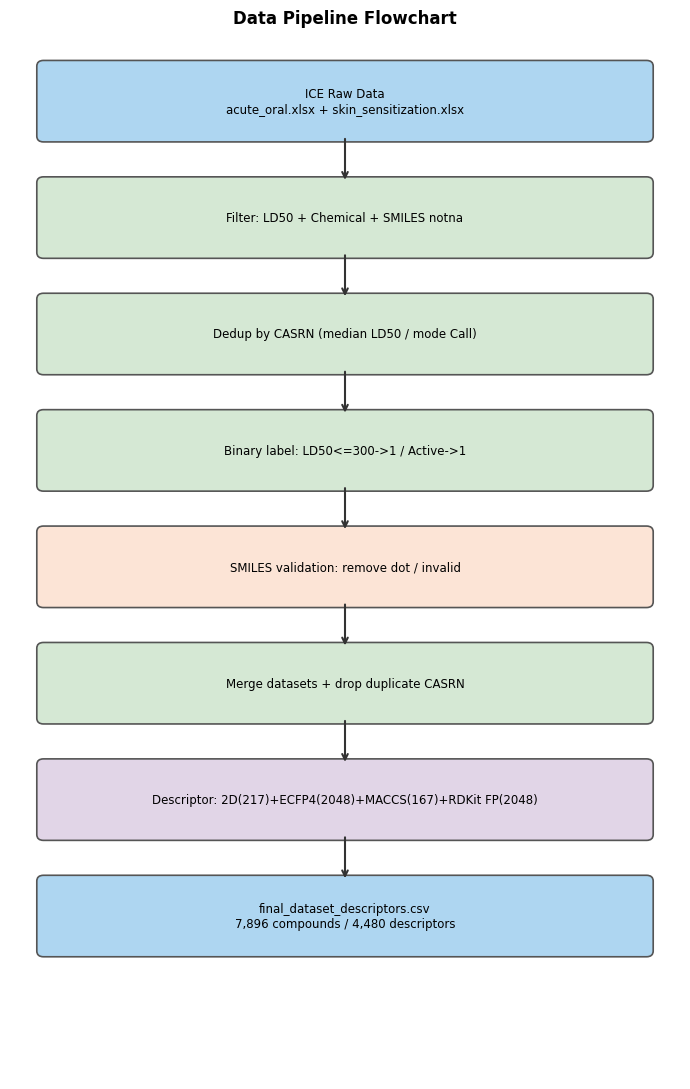

In [2]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis('off')

boxes = [
    ('ICE Raw Data\nacute_oral.xlsx + skin_sensitization.xlsx', 16.8, '#AED6F1'),
    ('Filter: LD50 + Chemical + SMILES notna', 14.8, '#D5E8D4'),
    ('Dedup by CASRN (median LD50 / mode Call)', 12.8, '#D5E8D4'),
    ('Binary label: LD50<=300->1 / Active->1', 10.8, '#D5E8D4'),
    ('SMILES validation: remove dot / invalid', 8.8, '#FCE4D6'),
    ('Merge datasets + drop duplicate CASRN', 6.8, '#D5E8D4'),
    ('Descriptor: 2D(217)+ECFP4(2048)+MACCS(167)+RDKit FP(2048)', 4.8, '#E1D5E7'),
    ('final_dataset_descriptors.csv\n7,896 compounds / 4,480 descriptors', 2.8, '#AED6F1'),
]

for text, y, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.5, y-0.6), 9, 1.2,
        boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='#555', linewidth=1.2
    ))
    ax.text(5, y, text, ha='center', va='center', fontsize=8.5)

for y_start, y_end in zip([16.2,14.2,12.2,10.2,8.2,6.2,4.2],
                           [15.4,13.4,11.4,9.4,7.4,5.4,3.4]):
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

ax.set_title('Data Pipeline Flowchart', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
# LD50 + 단일화합물만 필터링 후 화합물별 중앙값 계산
df = pd.read_excel('acute_oral.xlsx', sheet_name='Data')
df = df[(df['Endpoint']=='LD50') & (df['Mixture']=='Chemical') & df['SMILES'].notna()]
df = df.groupby('CASRN').agg(
    LD50_median=('Response','median'),
    SMILES=('SMILES','first'),
    Chemical_Name=('Chemical_Name','first')
).reset_index()

print('화합물 수:', len(df))

화합물 수: 8794


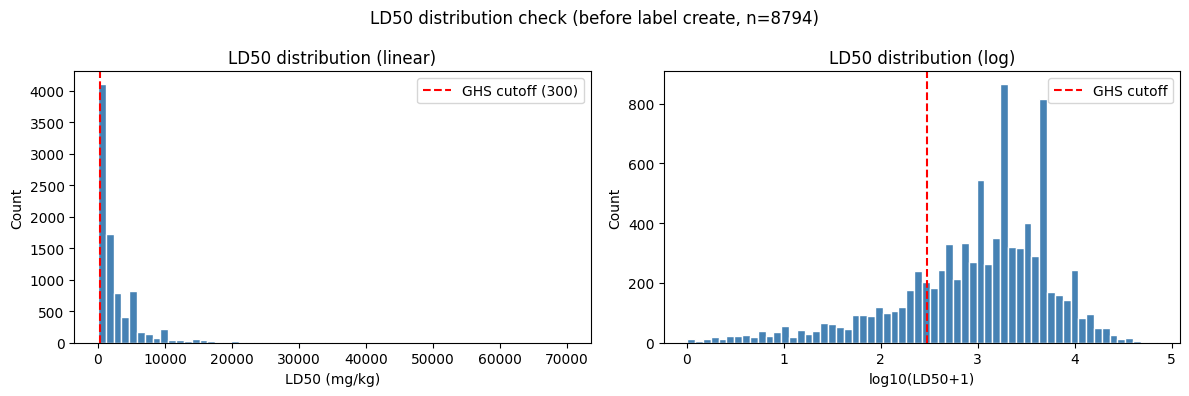

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['LD50_median'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(300, color='red', linestyle='--', label='GHS cutoff (300)')
axes[0].set(title='LD50 distribution (linear)', xlabel='LD50 (mg/kg)', ylabel='Count')
axes[0].legend()

axes[1].hist(np.log10(df['LD50_median']+1), bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(np.log10(300), color='red', linestyle='--', label='GHS cutoff')
axes[1].set(title='LD50 distribution (log)', xlabel='log10(LD50+1)', ylabel='Count')
axes[1].legend()

plt.suptitle(f'LD50 distribution check (before label create, n={len(df)})')
plt.tight_layout()
plt.show()

### LD50 분포 확인 결과
- 분포가 오른쪽으로 치우쳐 있어 (right-skewed) → log 변환 시 더 고르게 분포됨
- GHS cutoff(300 mg/kg) 기준으로 왼쪽(Toxic)이 오른쪽(Non-toxic)보다 훨씬 적음
- 커트라인 주변에 화합물이 밀집되지 않아 → GHS 기준 300 mg/kg 적용 적절

In [5]:
# GHS 기준: LD50 <= 300 mg/kg → Toxic(1), 초과 → Non-toxic(0)
df['label'] = (df['LD50_median'] <= 300).astype(int)
print(f'label 분포: {df["label"].value_counts().to_dict()}')

label 분포: {0: 6849, 1: 1945}


In [6]:
# dot 포함(염/혼합물) + invalid SMILES 제거
def check_smiles(smi):
    if '.' in str(smi): return 'dot'
    if Chem.MolFromSmiles(str(smi)) is None: return 'invalid'
    return 'valid'

df['status'] = df['SMILES'].apply(check_smiles)
print(df['status'].value_counts())

# valid만 남기기
df = df[df['status'] == 'valid'].reset_index(drop=True)
print(f'최종 유효 화합물: {len(df)}')

status
valid      7309
dot        1481
invalid       4
Name: count, dtype: int64
최종 유효 화합물: 7309


In [7]:
# PubChem API로 dot/invalid SMILES 보충 시도
# → 조회 결과 단일 SMILES 대체 불가 (염 형태는 PubChem에서도 동일하게 dot 포함 SMILES 반환)
# → 아래 코드는 참고용으로 남겨두며, 실제 실행은 생략

if False:
    def fetch_smiles_pubchem(casrn):
        url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{casrn}/property/CanonicalSMILES/JSON'
        try:
            r = requests.get(url, timeout=5)
            if r.status_code == 200:
                return r.json()['PropertyTable']['Properties'][0]['CanonicalSMILES']
        except:
            pass
        return None

    def is_valid_single(smi):
        if smi is None or '.' in str(smi): return False
        return Chem.MolFromSmiles(str(smi)) is not None

    target = df[df['status'] != 'valid']
    for i, (idx, row) in enumerate(target.iterrows()):
        new_smi = fetch_smiles_pubchem(row['CASRN'])
        if is_valid_single(new_smi):
            df.at[idx, 'SMILES'] = new_smi
            df.at[idx, 'status'] = 'valid'
        if (i+1) % 100 == 0:
            print(f'  {i+1}/{len(target)} 완료')
        time.sleep(0.2)

In [8]:
# Call endpoint + 단일화합물만 필터링 후 화합물별 최빈값 레이블
df_skin = pd.read_excel('skin_sensitization.xlsx', sheet_name='Data_invivo')
df_skin = df_skin[
    (df_skin['Endpoint'] == 'Call') &
    (df_skin['Mixture'] == 'Chemical') &
    df_skin['SMILES'].notna()
].copy()

df_skin = df_skin.groupby('CASRN').agg(
    Response=('Response', lambda x: x.mode()[0]),
    SMILES=('SMILES', 'first'),
    Chemical_Name=('Chemical_Name', 'first')
).reset_index()

# Active → 1, Inactive → 0
df_skin['label'] = (df_skin['Response'] == 'Active').astype(int)
df_skin = df_skin.drop(columns='Response')

# SMILES 유효성 검사
df_skin = df_skin[df_skin['SMILES'].apply(check_smiles) == 'valid'].reset_index(drop=True)

print('Skin Sensitization 화합물 수:', len(df_skin))
print('label 분포:', df_skin['label'].value_counts().to_dict())

Skin Sensitization 화합물 수: 1117
label 분포: {0: 927, 1: 190}


## 데이터 통합 — Acute Oral Toxicity + Skin Sensitization

두 데이터셋 모두 NTP ICE에서 제공하는 독성 데이터이며,
"독성 있음(1) / 없음(0)" 이진 분류 문제로 레이블 체계가 동일하다.

- **Acute Oral Toxicity**: 경구 투여 시 전신 독성 (LD50 ≤ 300 mg/kg → Toxic)
- **Skin Sensitization**: 피부 접촉 시 감작 반응 (Active → Sensitizer)

두 데이터셋을 통합해 더 다양한 화합물 구조를 학습 데이터로 확보하고,
CASRN 기준으로 중복 화합물은 제거한다.

In [9]:
df['source']      = 'acute_oral'
df_skin['source'] = 'skin_sensitization'

df_combined = pd.concat(
    [df[['CASRN','Chemical_Name','SMILES','label','source']],
     df_skin[['CASRN','Chemical_Name','SMILES','label','source']]],
    ignore_index=True
)

# CASRN 중복 제거
df_combined = df_combined.drop_duplicates(subset='CASRN').reset_index(drop=True)

print('acute_oral:', len(df))
print('skin_sensitization:', len(df_skin))
print('합친 후 전체 화합물:', len(df_combined))
print('label 분포:', df_combined['label'].value_counts().to_dict())
print('데이터 출처:', df_combined['source'].value_counts().to_dict())

acute_oral: 7309
skin_sensitization: 1117
합친 후 전체 화합물: 7896
label 분포: {0: 6147, 1: 1749}
데이터 출처: {'acute_oral': 7309, 'skin_sensitization': 587}


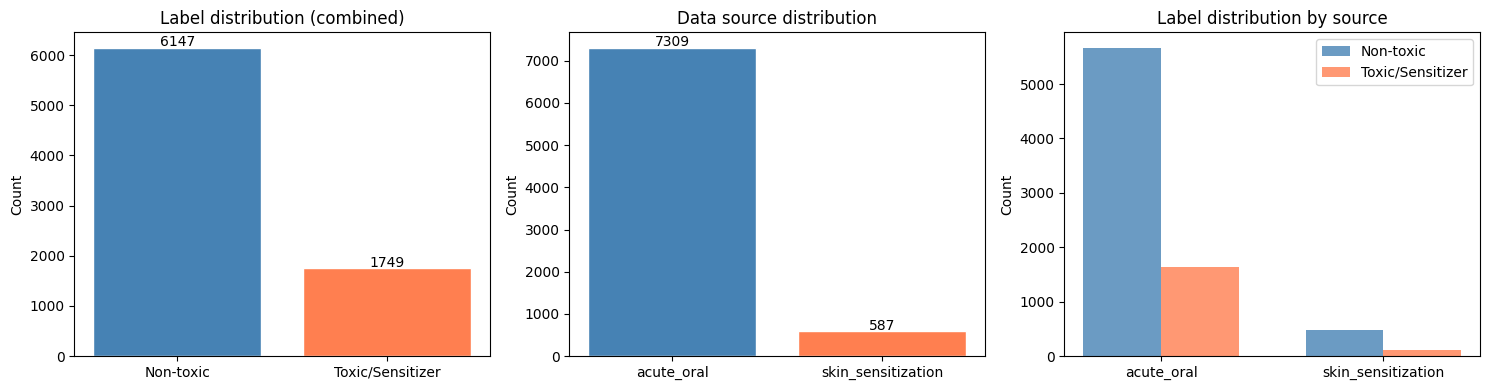

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vc = df_combined['label'].value_counts()
axes[0].bar(['Non-toxic','Toxic/Sensitizer'], vc.values,
            color=['steelblue','coral'], edgecolor='white')
for i, v in enumerate(vc.values): axes[0].text(i, v+30, str(v), ha='center')
axes[0].set(title='Label distribution (combined)', ylabel='Count')

sc = df_combined['source'].value_counts()
axes[1].bar(sc.index, sc.values, color=['steelblue','coral'], edgecolor='white')
for i, v in enumerate(sc.values): axes[1].text(i, v+30, str(v), ha='center')
axes[1].set(title='Data source distribution', ylabel='Count')

sources = df_combined['source'].unique()
x = np.arange(len(sources))
for offset, (lb, col, nm) in enumerate([(0,'steelblue','Non-toxic'),(1,'coral','Toxic/Sensitizer')]):
    vals = [df_combined[df_combined['source']==s]['label'].eq(lb).sum() for s in sources]
    axes[2].bar(x + offset*0.35, vals, 0.35, color=col, alpha=0.8, label=nm)
axes[2].set_xticks(x + 0.175)
axes[2].set_xticklabels(sources)
axes[2].set(title='Label distribution by source', ylabel='Count')
axes[2].legend()

plt.tight_layout()
plt.show()

In [11]:
# 4종 descriptor: 2D descriptor + ECFP4 + MACCS Keys + RDKit Fingerprint
desc_fns = Descriptors.descList
gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

rows, valid_idx, skipped = [], [], 0

for i, smi in enumerate(df_combined['SMILES']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    try:
        d2d   = [fn(mol) for _, fn in desc_fns]
        ecfp4 = list(gen.GetFingerprint(mol))
        maccs = list(rdMolDescriptors.GetMACCSKeysFingerprint(mol))
        rdkfp = list(Chem.RDKFingerprint(mol))
        rows.append(d2d + ecfp4 + maccs + rdkfp)
        valid_idx.append(i)
    except Exception:
        skipped += 1
        continue

print(f'에러로 스킵된 분자: {skipped}개')

df_combined = df_combined.iloc[valid_idx].reset_index(drop=True)

cols = ([n for n,_ in desc_fns]
      + [f'ECFP4_{i}'  for i in range(2048)]
      + [f'MACCS_{i}'  for i in range(167)]
      + [f'RDKFP_{i}'  for i in range(2048)])

df_desc = pd.DataFrame(rows, columns=cols)
print(f'2D descriptor : 217개')
print(f'ECFP4         : 2048개')
print(f'MACCS Keys    : 167개')
print(f'RDKit FP      : 2048개')
print(f'총             : {df_desc.shape[1]}개')
print(f'최종 화합물 수 : {len(df_combined)}개')

에러로 스킵된 분자: 0개
2D descriptor : 217개
ECFP4         : 2048개
MACCS Keys    : 167개
RDKit FP      : 2048개
총             : 4480개
최종 화합물 수 : 7896개


In [12]:
df_final = pd.concat(
    [df_combined[['CASRN','Chemical_Name','SMILES','label','source']], df_desc],
    axis=1
)
df_final.to_csv('final_dataset_descriptors.csv', index=False)
print('저장 완료:', df_final.shape)

저장 완료: (7896, 4485)


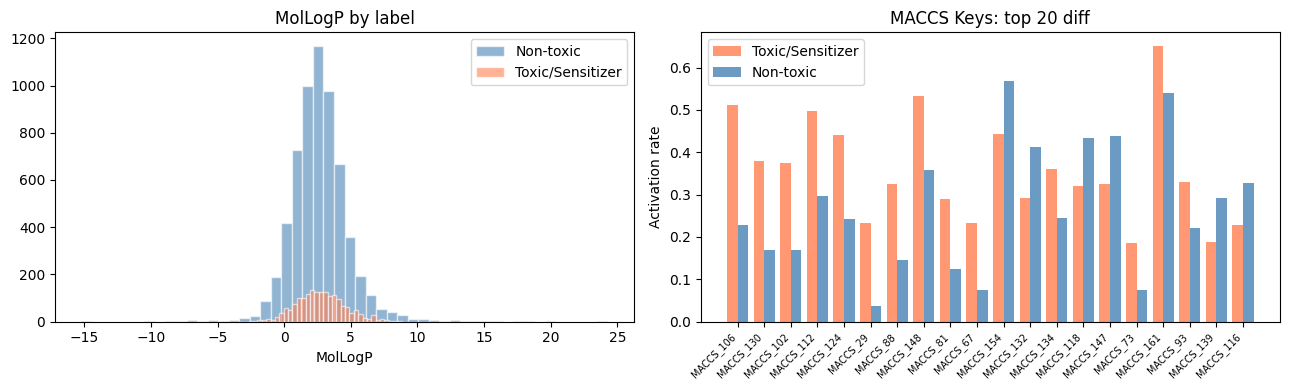

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lb, col, nm in [(0,'steelblue','Non-toxic'),(1,'coral','Toxic/Sensitizer')]:
    axes[0].hist(df_desc.loc[df_combined['label']==lb,'MolLogP'],
                 bins=50, alpha=0.6, color=col, label=nm, edgecolor='white')
axes[0].set(title='MolLogP by label', xlabel='MolLogP')
axes[0].legend()

maccs_cols = [c for c in df_desc.columns if c.startswith('MACCS')]
diff = (df_desc.loc[df_combined['label']==1, maccs_cols].mean()
      - df_desc.loc[df_combined['label']==0, maccs_cols].mean()).abs()
top20 = diff.nlargest(20)
x = np.arange(20)
axes[1].bar(x-0.2, df_desc.loc[df_combined['label']==1, top20.index].mean(),
            0.4, color='coral', alpha=0.8, label='Toxic/Sensitizer')
axes[1].bar(x+0.2, df_desc.loc[df_combined['label']==0, top20.index].mean(),
            0.4, color='steelblue', alpha=0.8, label='Non-toxic')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top20.index, rotation=45, ha='right', fontsize=7)
axes[1].set(title='MACCS Keys: top 20 diff', ylabel='Activation rate')
axes[1].legend()

plt.tight_layout()
plt.show()

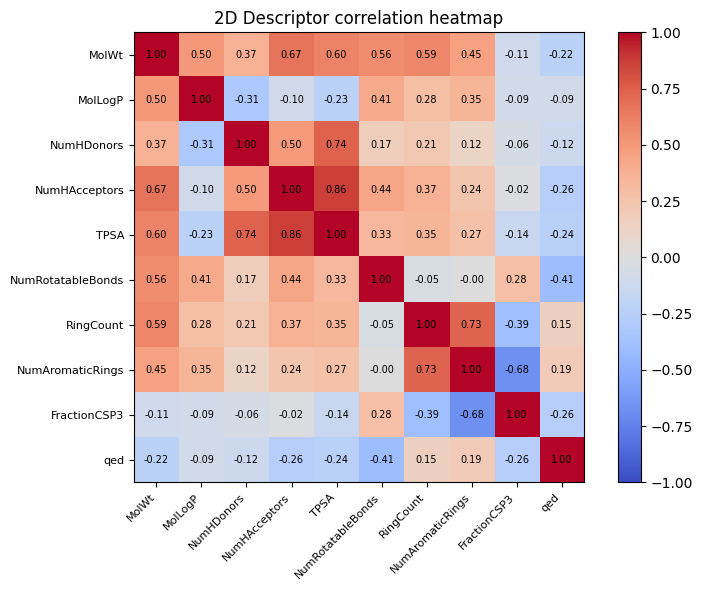

In [14]:
top_desc = ['MolWt','MolLogP','NumHDonors','NumHAcceptors',
            'TPSA','NumRotatableBonds','RingCount','NumAromaticRings','FractionCSP3','qed']
corr = df_desc[top_desc].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(top_desc, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(top_desc, fontsize=8)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('2D Descriptor correlation heatmap')
plt.tight_layout()
plt.show()

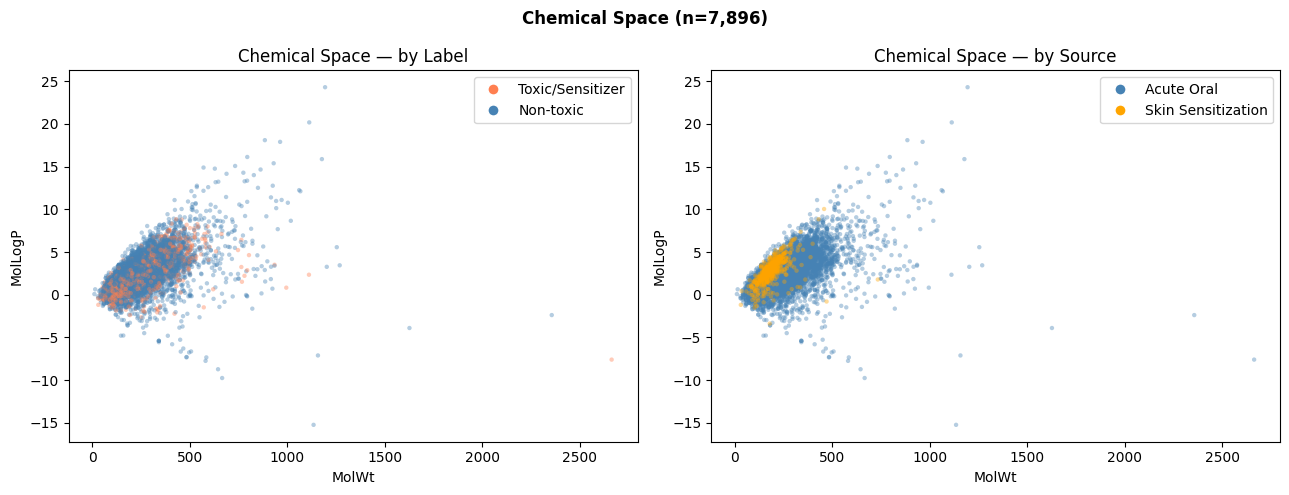

In [15]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_desc['MolWt'], df_desc['MolLogP'],
                c=df_combined['label'].map({0:'steelblue', 1:'coral'}),
                alpha=0.4, s=10, linewidths=0)
axes[0].set(title='Chemical Space — by Label', xlabel='MolWt', ylabel='MolLogP')
axes[0].legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',     markersize=8, label='Toxic/Sensitizer'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Non-toxic'),
])

axes[1].scatter(df_desc['MolWt'], df_desc['MolLogP'],
                c=df_combined['source'].map({'acute_oral':'steelblue','skin_sensitization':'orange'}),
                alpha=0.4, s=10, linewidths=0)
axes[1].set(title='Chemical Space — by Source', xlabel='MolWt', ylabel='MolLogP')
axes[1].legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Acute Oral'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='orange',    markersize=8, label='Skin Sensitization'),
])

plt.suptitle(f'Chemical Space (n={len(df_combined):,})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

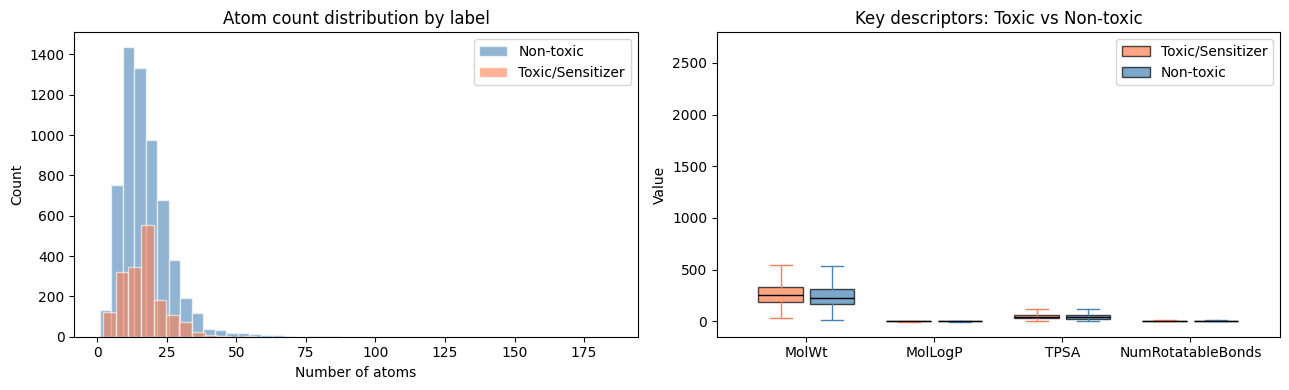

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

atom_counts = df_combined['SMILES'].apply(lambda s: Chem.MolFromSmiles(s).GetNumAtoms())
for lb, col, nm in [(0,'steelblue','Non-toxic'),(1,'coral','Toxic/Sensitizer')]:
    axes[0].hist(atom_counts[df_combined['label']==lb], bins=40,
                 alpha=0.6, color=col, label=nm, edgecolor='white')
axes[0].set(title='Atom count distribution by label', xlabel='Number of atoms', ylabel='Count')
axes[0].legend()

desc_box = ['MolWt','MolLogP','TPSA','NumRotatableBonds']
data_toxic    = [df_desc.loc[df_combined['label']==1, d].values for d in desc_box]
data_nontoxic = [df_desc.loc[df_combined['label']==0, d].values for d in desc_box]
x = np.arange(len(desc_box))

bp1 = axes[1].boxplot(data_toxic,    positions=x-0.2, widths=0.35, patch_artist=True,
                      boxprops=dict(facecolor='coral',     alpha=0.7),
                      medianprops=dict(color='black'),
                      whiskerprops=dict(color='coral'),
                      capprops=dict(color='coral'),
                      flierprops=dict(marker=''))
bp2 = axes[1].boxplot(data_nontoxic, positions=x+0.2, widths=0.35, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7),
                      medianprops=dict(color='black'),
                      whiskerprops=dict(color='steelblue'),
                      capprops=dict(color='steelblue'),
                      flierprops=dict(marker=''))
axes[1].set_xticks(x)
axes[1].set_xticklabels(desc_box)
axes[1].set(title='Key descriptors: Toxic vs Non-toxic', ylabel='Value')
axes[1].legend([bp1['boxes'][0], bp2['boxes'][0]], ['Toxic/Sensitizer','Non-toxic'])

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (balanced_accuracy_score, accuracy_score,
                             roc_auc_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

df = pd.read_csv('final_dataset_descriptors.csv')
print('shape:', df.shape)
print('label:', df['label'].value_counts().to_dict())

shape: (7896, 4485)
label: {0: 6147, 1: 1749}


In [18]:
y = df['label']
X = df.drop(columns=['CASRN', 'Chemical_Name', 'SMILES', 'label', 'source'])

# NaN 열 제거 — train 기준으로 처리하기 위해 일단 전체에서 제거
X = X.dropna(axis=1)

# 저분산 열 제거
X = X.loc[:, X.std() >= 0.01]

print('전처리 후 X shape:', X.shape)
print('label 분포:', y.value_counts().to_dict())

전처리 후 X shape: (7896, 4455)
label 분포: {0: 6147, 1: 1749}


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

print(f'Train: {X_train.shape[0]}개  Toxic={y_train.sum()}  Non-toxic={(y_train==0).sum()}')
print(f'Test : {X_test.shape[0]}개  Toxic={y_test.sum()}  Non-toxic={(y_test==0).sum()}')
print(f'Train Toxic 비율: {y_train.mean():.1%}')
print(f'Test  Toxic 비율: {y_test.mean():.1%}')

Train: 6316개  Toxic=1399  Non-toxic=4917
Test : 1580개  Toxic=350  Non-toxic=1230
Train Toxic 비율: 22.2%
Test  Toxic 비율: 22.2%


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('표준화 완료')

표준화 완료


In [21]:
k_candidates = [5, 10, 20, 30, 40, 50, 70, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True)

records = []
for k in k_candidates:
    sel = SelectKBest(f_classif, k=k)
    Xtr = sel.fit_transform(X_train_scaled, y_train)
    Xte = sel.transform(X_test_scaled)

    clf = LogisticRegression(max_iter=1000)

    cv_bal = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    cv_auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    cv_f1  = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro').mean()

    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    records.append({
        'k': k,
        'cv_balanced_acc': round(cv_bal, 3), 'test_balanced_acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'cv_roc_auc':      round(cv_auc, 3), 'test_roc_auc':      round(roc_auc_score(y_test, y_prob), 3),
        'cv_f1_macro':     round(cv_f1, 3),  'test_f1_macro':     round(f1_score(y_test, y_pred, average='macro'), 3),
    })
    print(f'k={k:3d}  bal_acc CV={cv_bal:.3f}/Test={balanced_accuracy_score(y_test,y_pred):.3f}  '
          f'auc CV={cv_auc:.3f}/Test={roc_auc_score(y_test,y_prob):.3f}')

k_df = pd.DataFrame(records)
best_k = int(k_df.loc[k_df['cv_balanced_acc'].idxmax(), 'k'])
print(f'\n최적 k: {best_k}')

k=  5  bal_acc CV=0.600/Test=0.590  auc CV=0.680/Test=0.680
k= 10  bal_acc CV=0.596/Test=0.589  auc CV=0.687/Test=0.682
k= 20  bal_acc CV=0.624/Test=0.610  auc CV=0.714/Test=0.685
k= 30  bal_acc CV=0.623/Test=0.616  auc CV=0.734/Test=0.705
k= 40  bal_acc CV=0.634/Test=0.629  auc CV=0.742/Test=0.721
k= 50  bal_acc CV=0.641/Test=0.640  auc CV=0.741/Test=0.729
k= 70  bal_acc CV=0.654/Test=0.642  auc CV=0.764/Test=0.760
k=100  bal_acc CV=0.666/Test=0.664  auc CV=0.778/Test=0.763

최적 k: 100


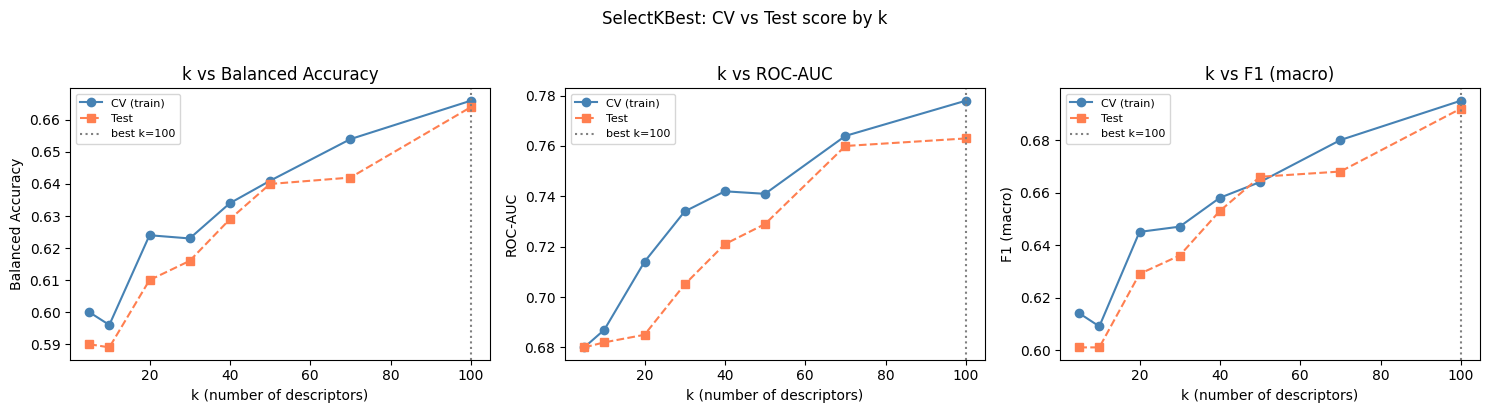

In [22]:
metrics = [('balanced_acc','Balanced Accuracy'), ('roc_auc','ROC-AUC'), ('f1_macro','F1 (macro)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (metric, title) in zip(axes, metrics):
    ax.plot(k_df['k'], k_df[f'cv_{metric}'],  marker='o', color='steelblue', label='CV (train)')
    ax.plot(k_df['k'], k_df[f'test_{metric}'], marker='s', color='coral',     label='Test', linestyle='--')
    ax.axvline(best_k, color='gray', linestyle=':', label=f'best k={best_k}')
    ax.set_xlabel('k (number of descriptors)')
    ax.set_ylabel(title)
    ax.set_title(f'k vs {title}')
    ax.legend(fontsize=8)

plt.suptitle('SelectKBest: CV vs Test score by k', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# 선형 모델용 (표준화 O)
selector = SelectKBest(f_classif, k=best_k)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

# 트리 모델용 (표준화 X)
selector_tree = SelectKBest(f_classif, k=best_k)
X_train_tree  = selector_tree.fit_transform(X_train, y_train)
X_test_tree   = selector_tree.transform(X_test)

selected_cols = X_train.columns[selector_tree.get_support()]
print('선택된 descriptor 수:', len(selected_cols))
print(list(selected_cols))

선택된 descriptor 수: 100
['MinEStateIndex', 'FpDensityMorgan1', 'SMR_VSA10', 'SlogP_VSA12', 'SlogP_VSA5', 'VSA_EState10', 'NumHeteroatoms', 'fr_Ar_NH', 'fr_C_O', 'fr_Nhpyrrole', 'ECFP4_24', 'ECFP4_97', 'ECFP4_116', 'ECFP4_192', 'ECFP4_353', 'ECFP4_486', 'ECFP4_601', 'ECFP4_793', 'ECFP4_799', 'ECFP4_809', 'ECFP4_819', 'ECFP4_853', 'ECFP4_956', 'ECFP4_1203', 'ECFP4_1453', 'ECFP4_1456', 'ECFP4_1716', 'ECFP4_1729', 'ECFP4_1795', 'MACCS_23', 'MACCS_29', 'MACCS_38', 'MACCS_48', 'MACCS_67', 'MACCS_73', 'MACCS_81', 'MACCS_88', 'MACCS_102', 'MACCS_106', 'MACCS_112', 'MACCS_124', 'MACCS_130', 'MACCS_148', 'RDKFP_81', 'RDKFP_118', 'RDKFP_146', 'RDKFP_212', 'RDKFP_237', 'RDKFP_311', 'RDKFP_324', 'RDKFP_387', 'RDKFP_408', 'RDKFP_469', 'RDKFP_504', 'RDKFP_518', 'RDKFP_550', 'RDKFP_585', 'RDKFP_662', 'RDKFP_669', 'RDKFP_676', 'RDKFP_706', 'RDKFP_709', 'RDKFP_758', 'RDKFP_759', 'RDKFP_770', 'RDKFP_774', 'RDKFP_844', 'RDKFP_858', 'RDKFP_878', 'RDKFP_972', 'RDKFP_1025', 'RDKFP_1031', 'RDKFP_1054', 'RDKFP_1

In [24]:
model_configs = {
    'LogReg': (LogisticRegression(max_iter=1000),              X_train_sel,  X_test_sel),
    'MLP':    (MLPClassifier(hidden_layer_sizes=(100,), max_iter=500), X_train_sel, X_test_sel),
    'SVM':    (SVC(probability=True),                           X_train_sel,  X_test_sel),
    'DT':     (DecisionTreeClassifier(max_depth=5),             X_train_tree, X_test_tree),
    'RF':     (RandomForestClassifier(n_estimators=100),        X_train_tree, X_test_tree),
    'XGB':    (XGBClassifier(n_estimators=100, eval_metric='logloss', verbosity=0), X_train_tree, X_test_tree),
}

cv_results = []
for name, (clf, Xtr, _) in model_configs.items():
    score = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    cv_results.append({'model': name, 'cv_balanced_acc': round(score, 3)})
    print(f'{name:8s}  CV Balanced Acc={score:.3f}')

cv_df = pd.DataFrame(cv_results).sort_values('cv_balanced_acc', ascending=False)
print('\n=== CV 기준 모델 순위 ===')
print(cv_df.to_string(index=False))

LogReg    CV Balanced Acc=0.666
MLP       CV Balanced Acc=0.720
SVM       CV Balanced Acc=0.688
DT        CV Balanced Acc=0.638
RF        CV Balanced Acc=0.722
XGB       CV Balanced Acc=0.727

=== CV 기준 모델 순위 ===
 model  cv_balanced_acc
   XGB            0.727
    RF            0.722
   MLP            0.720
   SVM            0.688
LogReg            0.666
    DT            0.638


In [25]:
final_results = []

for name, (clf, Xtr, Xte) in model_configs.items():
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1] if hasattr(clf, 'predict_proba') else clf.decision_function(Xte)

    final_results.append({
        'model':        name,
        'balanced_acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'accuracy':     round(accuracy_score(y_test, y_pred), 3),
        'roc_auc':      round(roc_auc_score(y_test, y_prob), 3),
        'f1_macro':     round(f1_score(y_test, y_pred, average='macro'), 3),
    })

final_df = pd.DataFrame(final_results).sort_values('balanced_acc', ascending=False)
print('=== Test 셋 최종 평가 ===')
print(final_df.to_string(index=False))

=== Test 셋 최종 평가 ===
 model  balanced_acc  accuracy  roc_auc  f1_macro
   MLP         0.735     0.836    0.800     0.748
   XGB         0.735     0.853    0.824     0.761
    RF         0.733     0.862    0.843     0.766
   SVM         0.688     0.850    0.807     0.725
LogReg         0.664     0.827    0.763     0.692
    DT         0.637     0.827    0.725     0.665


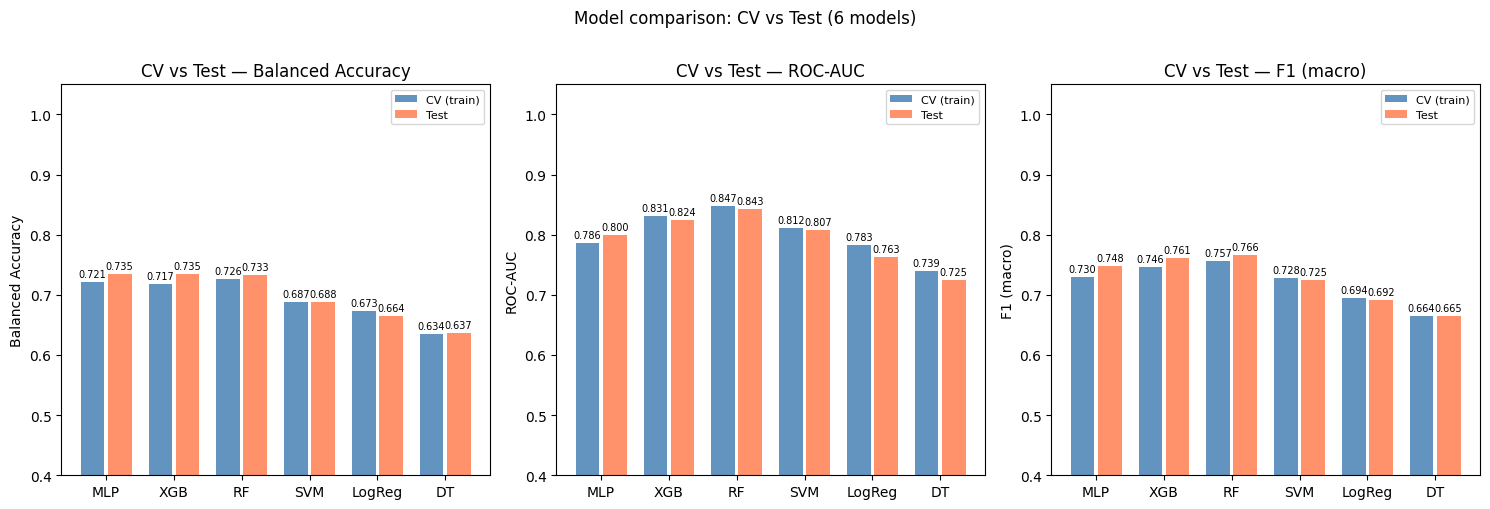

In [26]:
# CV vs Test 점수 비교
cv_detail = []
for name, (clf, Xtr, _) in model_configs.items():
    bal = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    f1  = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro').mean()
    cv_detail.append({'model': name, 'cv_balanced_acc': bal, 'cv_roc_auc': auc, 'cv_f1_macro': f1})

cv_detail_df = pd.DataFrame(cv_detail)
compare_df   = final_df.merge(cv_detail_df, on='model')

metrics_info = [
    ('cv_balanced_acc', 'balanced_acc', 'Balanced Accuracy'),
    ('cv_roc_auc',      'roc_auc',      'ROC-AUC'),
    ('cv_f1_macro',     'f1_macro',     'F1 (macro)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (cv_col, test_col, title) in zip(axes, metrics_info):
    x = np.arange(len(compare_df))
    bars1 = ax.bar(x - 0.2, compare_df[cv_col],   0.35, color='steelblue', alpha=0.85, label='CV (train)')
    bars2 = ax.bar(x + 0.2, compare_df[test_col], 0.35, color='coral',     alpha=0.85, label='Test')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df['model'])
    ax.set_ylabel(title)
    ax.set_title(f'CV vs Test — {title}')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model comparison: CV vs Test (6 models)', y=1.01)
plt.tight_layout()
plt.show()

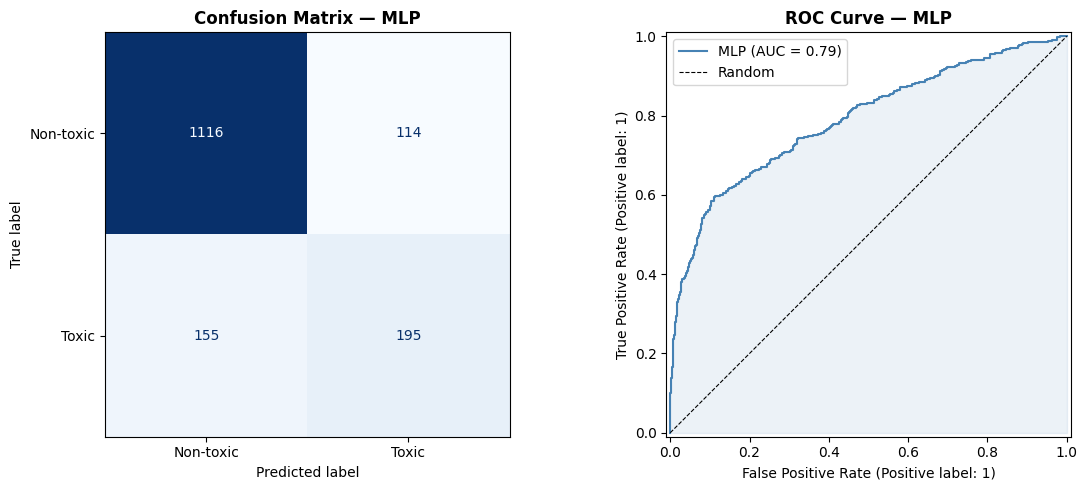


=== MLP Classification Report ===
              precision    recall  f1-score   support

   Non-toxic       0.88      0.91      0.89      1230
       Toxic       0.63      0.56      0.59       350

    accuracy                           0.83      1580
   macro avg       0.75      0.73      0.74      1580
weighted avg       0.82      0.83      0.83      1580



In [29]:
best_name = final_df.iloc[0]['model']
best_clf, best_Xtr, best_Xte = model_configs[best_name]
best_clf.fit(best_Xtr, y_train)
y_pred_best = best_clf.predict(best_Xte)
y_prob_best = best_clf.predict_proba(best_Xte)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Non-toxic', 'Toxic'],
    ax=axes[0], colorbar=False,
    cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob_best, ax=axes[1],
    name=best_name, color='steelblue'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
axes[1].fill_between(
    axes[1].lines[0].get_xdata(),
    axes[1].lines[0].get_ydata(),
    alpha=0.1, color='steelblue'
)
axes[1].set_title(f'ROC Curve — {best_name}', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n=== {best_name} Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Non-toxic','Toxic']))

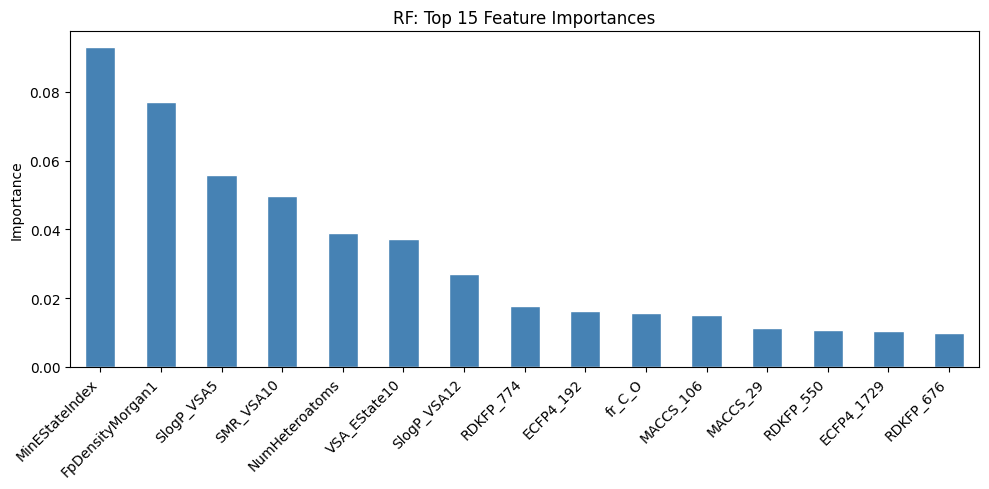

Top 10 important descriptors:
MinEStateIndex      0.092960
FpDensityMorgan1    0.077124
SlogP_VSA5          0.055757
SMR_VSA10           0.049681
NumHeteroatoms      0.038978
VSA_EState10        0.037240
SlogP_VSA12         0.027143
RDKFP_774           0.017681
ECFP4_192           0.016262
fr_C_O              0.015813


In [28]:
fi_name = 'RF'
fi_clf, fi_Xtr, _ = model_configs[fi_name]
fi_clf.fit(fi_Xtr, y_train)

feat_imp = pd.Series(fi_clf.feature_importances_, index=selected_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'{fi_name}: Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 important descriptors:')
print(feat_imp.head(10).to_string())